# PRIS — 02. Placement Readiness ML Model
Trains the classifier described in the PRIS spec:
- **Input:** the 10 Feature-Builder numeric features
- **Target:** `readiness_label` (Highly Ready / Moderately Ready / Needs Improvement / Not Ready Yet)
- Compares Logistic Regression, Decision Tree, Random Forest, Gradient Boosting
- Saves `models/readiness_model.pkl`, `scaler.pkl`, `label_encoder.pkl`, `metadata.pkl`
  for `app.py` to load directly (no retraining needed to run the Streamlit app).

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
os.makedirs("models", exist_ok=True)

## 1. Load Processed Data

In [2]:
df = pd.read_csv("student_placement_processed.csv")

FEATURE_COLS = [
    "skill_match_percentage", "critical_skill_match_percentage",
    "missing_skills_count", "critical_missing_skills_count",
    "project_relevance_score", "certification_relevance_score",
    "internship_relevance_score", "resume_completeness_score",
    "keyword_match_score", "role_category_match_score",
]

X = df[FEATURE_COLS].values
y_raw = df["readiness_label"].values

le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Classes:", list(le.classes_))
print("X shape:", X.shape)

Classes: ['Highly Ready', 'Moderately Ready', 'Needs Improvement', 'Not Ready Yet']
X shape: (100000, 10)


## 2. Train / Test Split + Scaling

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (80000, 10)  Test: (20000, 10)


## 3. Train & Compare Models

In [4]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    Xtr = X_train_s if name == "LogisticRegression" else X_train
    Xte = X_test_s if name == "LogisticRegression" else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average="macro")
    results[name] = dict(model=model, acc=acc, prec=prec, rec=rec, f1=f1, preds=preds)
    print(f"{name:18s} acc={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}")

results_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "model" and kk != "preds"} for k, v in results.items()}).T
results_df

LogisticRegression acc=0.6167  precision=0.6136  recall=0.6166  f1=0.6147
DecisionTree       acc=0.5562  precision=0.5704  recall=0.5562  f1=0.5568
RandomForest       acc=0.6082  precision=0.6080  recall=0.6082  f1=0.6053
GradientBoosting   acc=0.6198  precision=0.6208  recall=0.6198  f1=0.6193


,acc,prec,rec,f1
LogisticRegression,0.61665,0.613561,0.61665,0.614744
DecisionTree,0.55620,0.570361,0.55620,0.556837
RandomForest,0.60820,0.607956,0.60820,0.605298
GradientBoosting,0.61980,0.620790,0.61980,0.619310


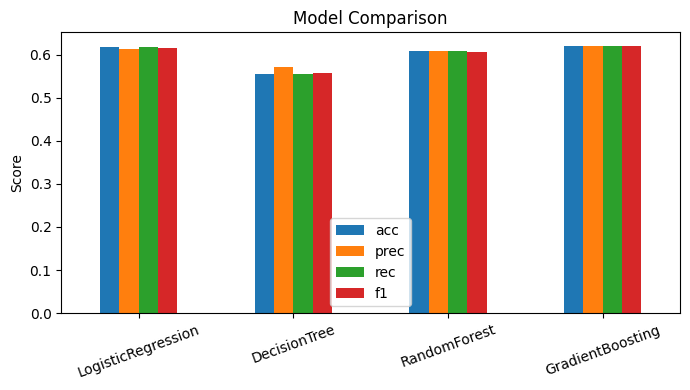

In [5]:
plt.figure(figsize=(7, 4))
results_df[["acc", "prec", "rec", "f1"]].plot(kind="bar", ax=plt.gca())
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4. Select Best Model

In [6]:
best_name = max(results, key=lambda k: results[k]["f1"])
best_model = results[best_name]["model"]
best_preds = results[best_name]["preds"]
print("Best model:", best_name)

print(classification_report(y_test, best_preds, target_names=le.classes_))

Best model: GradientBoosting
                   precision    recall  f1-score   support

     Highly Ready       0.75      0.79      0.77      5000
 Moderately Ready       0.52      0.58      0.55      5000
Needs Improvement       0.49      0.46      0.48      5000
    Not Ready Yet       0.72      0.65      0.68      5000

         accuracy                           0.62     20000
        macro avg       0.62      0.62      0.62     20000
     weighted avg       0.62      0.62      0.62     20000



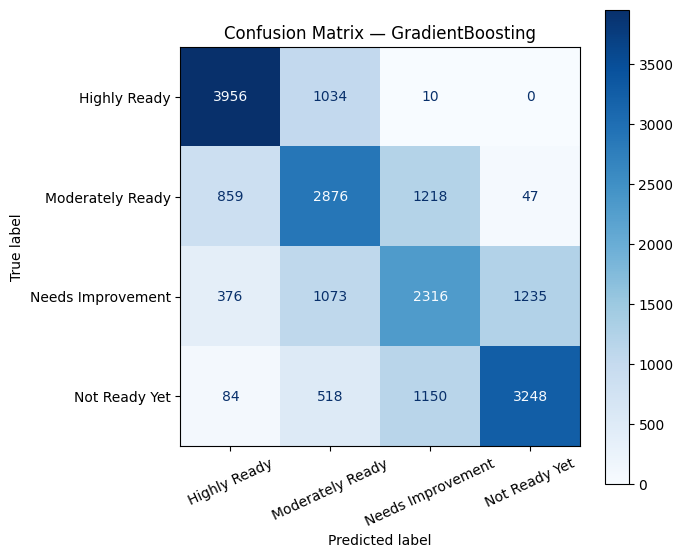

In [7]:
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=25)
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

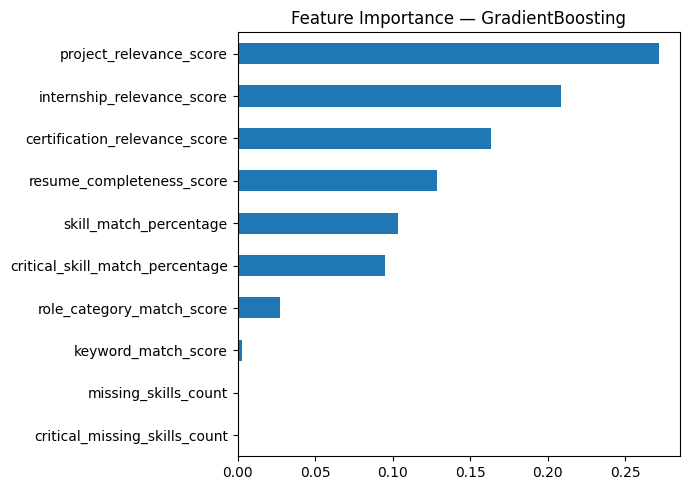

In [8]:
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values()
    plt.figure(figsize=(7, 5))
    imp.plot(kind="barh")
    plt.title(f"Feature Importance — {best_name}")
    plt.tight_layout()
    plt.show()

## 5. Save Artifacts for the Streamlit App

In [10]:
joblib.dump(best_model, "readiness_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump({
    "feature_columns": FEATURE_COLS,
    "best_model_name": best_name,
    "uses_scaler": best_name == "LogisticRegression",
    "class_score_midpoint": {
        "Not Ready Yet": 20, "Needs Improvement": 45,
        "Moderately Ready": 65, "Highly Ready": 90,
    },
}, "metadata.pkl")

print("Saved:")
for f in ["readiness_model.pkl", "scaler.pkl", "label_encoder.pkl", "metadata.pkl"]:
    print(" -", f)

Saved:
 - readiness_model.pkl
 - scaler.pkl
 - label_encoder.pkl
 - metadata.pkl
